In [14]:
# loading libraries for data manipulation
import numpy as np
import pandas as pd

# loading libraries for data visualization
import matplotlib.pyplot as plt
from plotnine import *

# import tensorflow and keras packages
import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')

In [15]:
# function will take a NN history and plot the training/validation loss and accuracy per epoch
def evaluation_plots(model_history):
    # Extract metrics from the history object
    history_dict = model_history.history
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    accuracy = history_dict['accuracy']
    val_accuracy = history_dict['val_accuracy']

    epochs = range(1, len(loss) + 1)

    # Create a figure with 2 subplots (side-by-side)
    plt.figure(figsize=(14, 5))

    # Plot 1: Loss Curves
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'r--', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'b-', label='Validation Loss', linewidth=2)
    plt.title('Training and Validation Loss (No Regularization)', fontsize=12)
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    plt.legend(fontsize=10)
    plt.grid(True)

    # Plot 2: Accuracy Curves
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, 'r--', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_accuracy, 'b-', label='Validation Accuracy', linewidth=2)
    plt.title('Training and Validation Accuracy (No Regularization)', fontsize=12)
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Accuracy', fontsize=10)
    plt.legend(fontsize=10)
    plt.grid(True)

    plt.tight_layout()
    plt.show()


For this exercise, we will use a new dataset called Fashion MNIST. More details here: https://keras.io/api/datasets/fashion_mnist/ 

In [16]:
# Load the Fashion MNIST data
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = keras.datasets.fashion_mnist.load_data()

Visualize some examples from the dataset

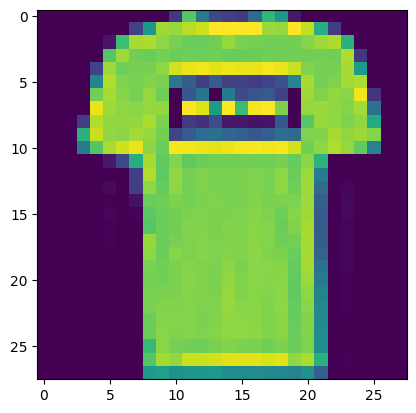

In [ ]:
plt.imshow(X_train_mnist[0])

Let's flatten the images and one-hot encode the target. 

In [21]:
X_train_mnist = X_train_mnist.reshape(-1, 28*28).astype('float32') / 255.0
X_test_mnist = X_test_mnist.reshape(-1, 28*28).astype('float32') / 255.0

# Convert y labels to one-hot encoded vectors
y_train_mnist = keras.utils.to_categorical(y_train_mnist, num_classes=10)
y_test_mnist = keras.utils.to_categorical(y_test_mnist, num_classes=10)



Regularization techniques ensure that a deep neural network is generalized, and avoids overfitting in particular. Some techniques we can employ:
- Penalization
- Dropout
- Batch Normalization
- Early Stopping

Let's first build a deep neural network to classify digits without any regularization

In [22]:
model = keras.Sequential([
        keras.layers.Dense(256,activation='relu',input_shape=(784,)),
        keras.layers.Dense(256,activation='relu'),
        keras.layers.Dense(10,activation='softmax')
    ])

model.compile(loss="categorical_crossentropy",
              optimizer="adam", 
              metrics=["accuracy"])

history_no_reg = model.fit(X_train_mnist,y_train_mnist,
                           epochs=20,verbose=1,batch_size=128,
                           validation_data=(X_test_mnist,y_test_mnist))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8170 - loss: 0.5129 - val_accuracy: 0.8542 - val_loss: 0.4088
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8678 - loss: 0.3646 - val_accuracy: 0.8593 - val_loss: 0.3882
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8812 - loss: 0.3244 - val_accuracy: 0.8672 - val_loss: 0.3803
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8883 - loss: 0.3018 - val_accuracy: 0.8775 - val_loss: 0.3378
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8953 - loss: 0.2816 - val_accuracy: 0.8806 - val_loss: 0.3391
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9008 - loss: 0.2673 - val_accuracy: 0.8806 - val_loss: 0.3293
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9050 - loss: 0.2522 - val_accuracy: 0.8867 - val_loss: 0.3175
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9097 - loss: 0.2393 - val_accuracy: 0.

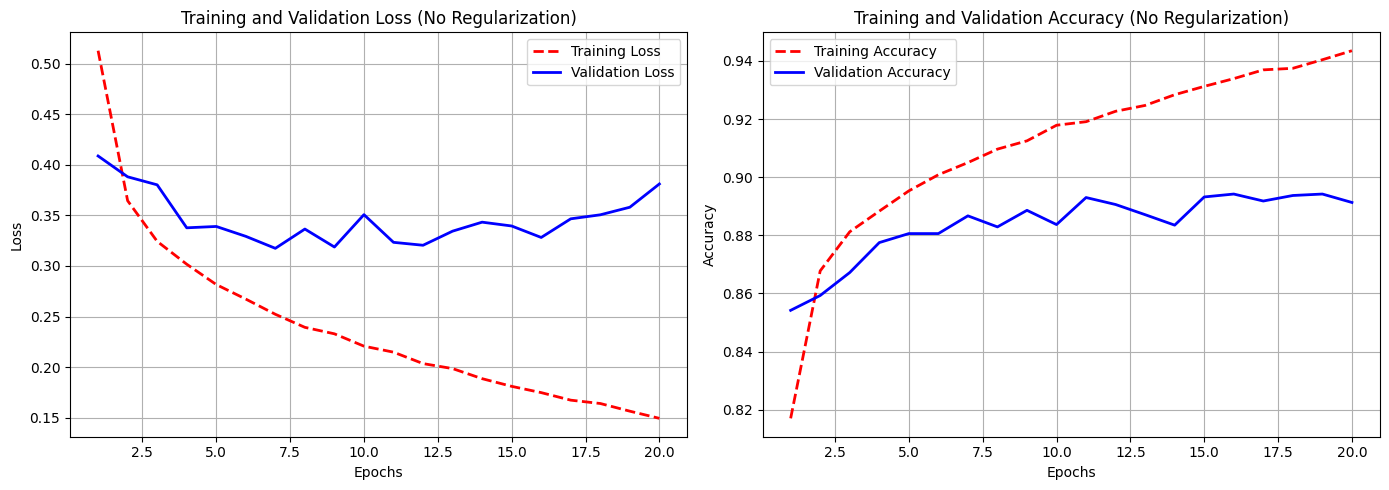

In [23]:
evaluation_plots(history_no_reg)

The overfitting is quite apparent here.

Let's introduce L2 weight regularization. This is theoretically a weight decay which will ensure that weights remain small and not one neuron influences inferences. 

In [24]:
model = keras.Sequential([
        keras.layers.Dense(256,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001),input_shape=(784,)),
        keras.layers.Dense(256,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.Dense(10,activation='softmax') # output layer
    ])

model.compile(loss="categorical_crossentropy",
              optimizer="adam", 
              metrics=["accuracy"])

history_l2_reg = model.fit(X_train_mnist,y_train_mnist,
                           epochs=20,verbose=1,batch_size=128,
                           validation_data=(X_test_mnist,y_test_mnist))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8174 - loss: 0.8703 - val_accuracy: 0.8156 - val_loss: 0.7315
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8559 - loss: 0.6018 - val_accuracy: 0.8513 - val_loss: 0.5866
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8661 - loss: 0.5161 - val_accuracy: 0.8548 - val_loss: 0.5277
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8709 - loss: 0.4728 - val_accuracy: 0.8555 - val_loss: 0.5005
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8742 - loss: 0.4481 - val_accuracy: 0.8603 - val_loss: 0.4821
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8775 - loss: 0.4287 - val_accuracy: 0.8637 - val_loss: 0.4583
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8793 - loss: 0.4197 - val_accuracy: 0.8624 - val_loss: 0.4640
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8812 - loss: 0.4094 - val_accuracy: 0.

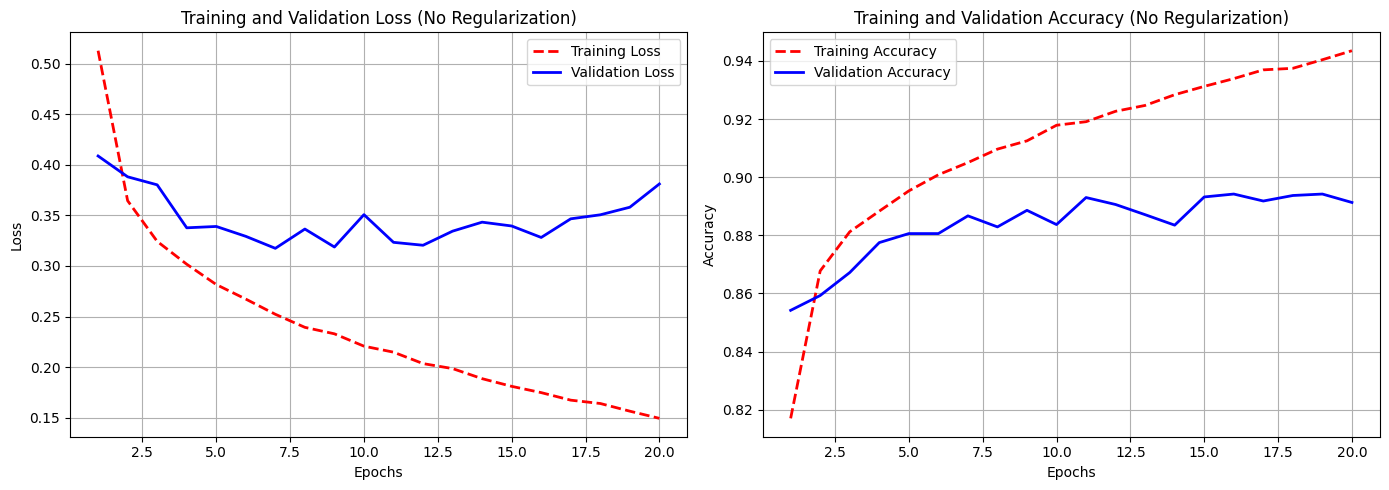

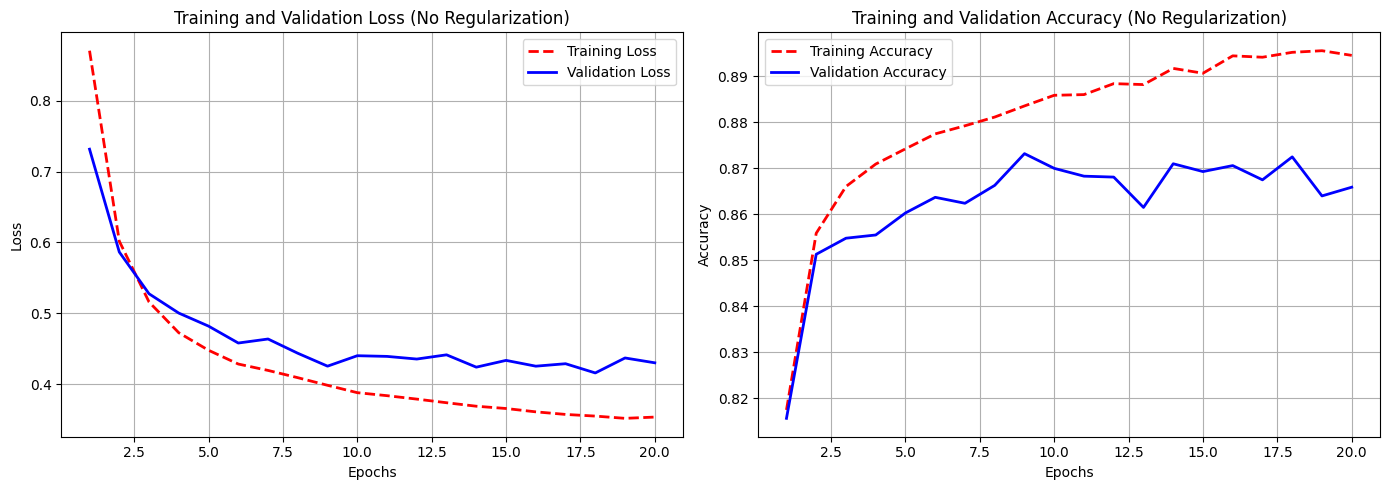

In [25]:
evaluation_plots(history_no_reg)
evaluation_plots(history_l2_reg)

Let's also introduce Dropout. Dropout with a probability p will randomly drop neurons from network during training. 

In [26]:
model = keras.Sequential([
        keras.layers.Dense(256,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001),input_shape=(784,)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(256,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10,activation='softmax') # output layer
    ])

model.compile(loss="categorical_crossentropy",
              optimizer="adam", 
              metrics=["accuracy"])

history_l2_drop_reg = model.fit(X_train_mnist,y_train_mnist,
                           epochs=20,verbose=1,batch_size=128,
                           validation_data=(X_test_mnist,y_test_mnist))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7990 - loss: 0.9120 - val_accuracy: 0.8433 - val_loss: 0.6683
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8475 - loss: 0.6161 - val_accuracy: 0.8511 - val_loss: 0.5635
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8540 - loss: 0.5442 - val_accuracy: 0.8539 - val_loss: 0.5287
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.5100 - val_accuracy: 0.8503 - val_loss: 0.5219
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8601 - loss: 0.4903 - val_accuracy: 0.8666 - val_loss: 0.4799
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8621 - loss: 0.4800 - val_accuracy: 0.8562 - val_loss: 0.4915
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8639 - loss: 0.4702 - val_accuracy: 0.8618 - val_loss: 0.4709
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8644 - loss: 0.4662 - val_accuracy: 0.

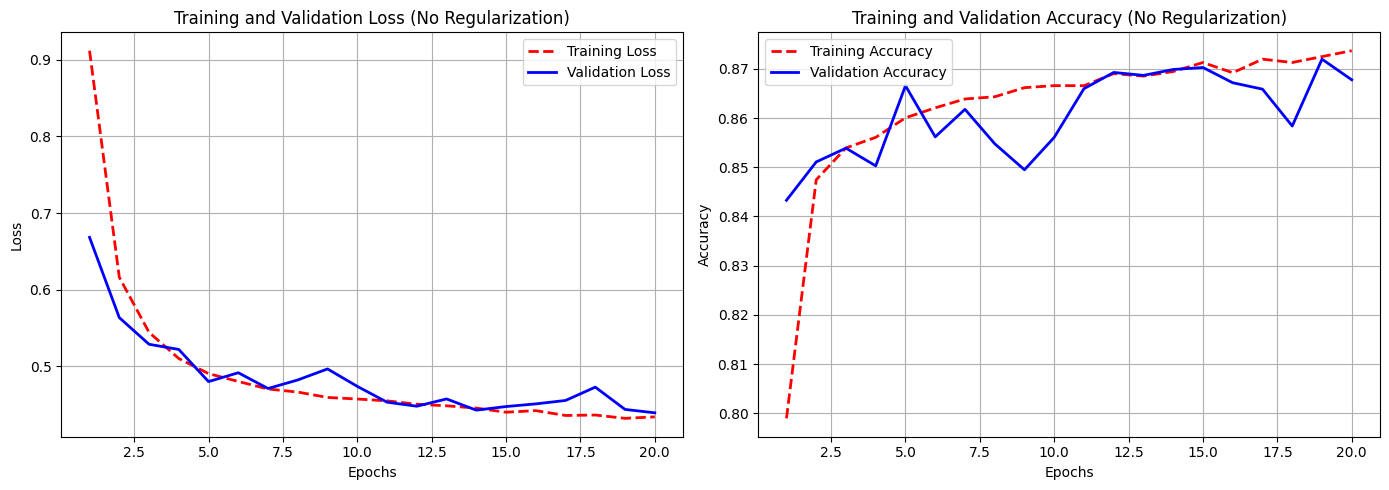

In [27]:
evaluation_plots(history_l2_drop_reg)

Another option would be to use Early Stopping. This mechanism stops training when validation loss stops improving, preventing overfitting. We can use the EarlyStopping callback. 

In [28]:
model = keras.Sequential([
        keras.layers.Dense(256,activation='relu',input_shape=(784,)),
        keras.layers.Dense(256,activation='relu'),
        keras.layers.Dense(10,activation='softmax')
    ])

model.compile(loss="categorical_crossentropy",
              optimizer="adam", 
              metrics=["accuracy"])

early_stopping = keras.callbacks.EarlyStopping(
    monitor = "val_loss", # track validation loss
    patience = 2, # wait 2 epochs for improvement
    restore_best_weights = True # use best weights learned as final set
)

history_no_reg_early_stop = model.fit(X_train_mnist,y_train_mnist,
                           epochs=20,verbose=1,batch_size=128,
                           validation_data=(X_test_mnist,y_test_mnist),
                           callbacks=[early_stopping])

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8245 - loss: 0.4994 - val_accuracy: 0.8573 - val_loss: 0.3960
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8692 - loss: 0.3609 - val_accuracy: 0.8645 - val_loss: 0.3762
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8816 - loss: 0.3255 - val_accuracy: 0.8699 - val_loss: 0.3667
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8917 - loss: 0.2979 - val_accuracy: 0.8631 - val_loss: 0.3645
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8955 - loss: 0.2815 - val_accuracy: 0.8736 - val_loss: 0.3457
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9018 - loss: 0.2627 - val_accuracy: 0.8651 - val_loss: 0.3655
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9049 - loss: 0.2555 - val_accuracy: 0.8748 - val_loss: 0.3459


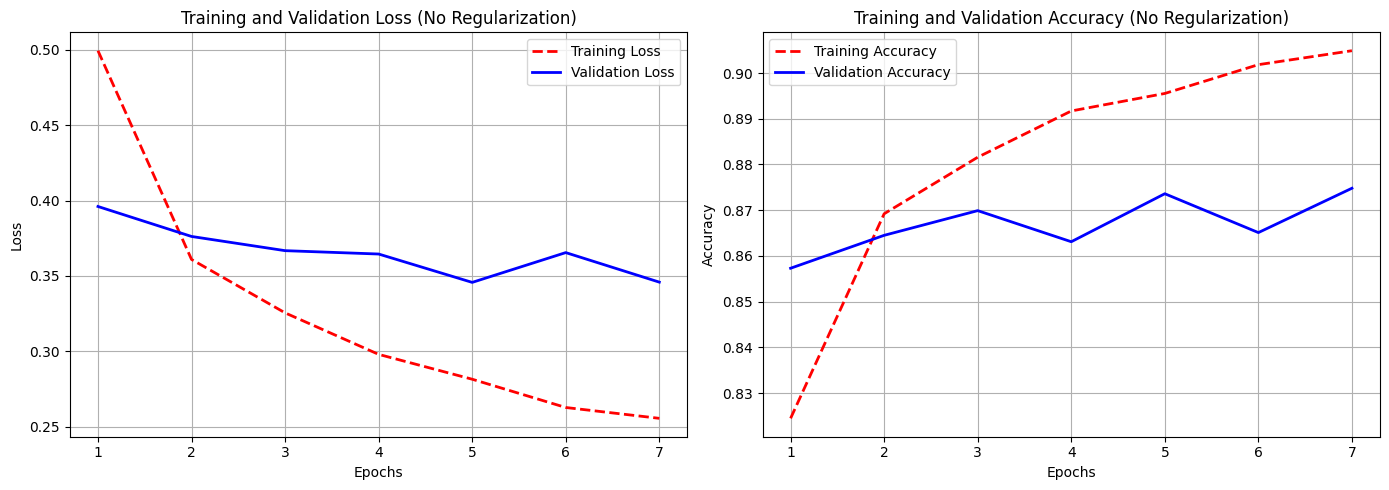

In [29]:
evaluation_plots(history_no_reg_early_stop)

Our last regularization step (not including data augmentation), is Batch Normalization. This normalizes activations of each layer to mean = 0 and std = 1, per mini-batch. It stabilizes and speeds up training. Note that we can apply Batch Normalization before the activation function is applied. That is, normalize the weight sum and then apply an activation function on top. You can apply Batch Normalization after activation function as well, but be careful as ReLU can result in a lot of 0s.  

In [ ]:
model = keras.Sequential([
        keras.layers.Dense(256,activation='relu',input_shape=(784,)),
        keras.layers.Dense(256,activation='relu'),
        keras.layers.Dense(10,activation='softmax') # output layer
    ])

model.compile(loss="categorical_crossentropy",
              optimizer="adam", 
              metrics=["accuracy"])


history_no_reg = model.fit(X_train_mnist,y_train_mnist,
                           epochs=5,verbose=1,batch_size=128,
                           validation_data=(X_test_mnist,y_test_mnist))

In [ ]:
model.summary()

This does mean that the network now has to learn more parameters throughout the network. 

Traditionally, the layout for a feed forward neural network should be
1. Define Input Shape
2. Add N Hidden Layers, and for each, add L2 regularization, Activation Function, Batch Normalization (before/after activation)
3. Add Dropout between layers (after activation)
4. Define Output Layer with task-depended activation function (softmax for classification, sigmoid for binary, none for regression/linear)
5. Define Optimizer, Loss Function
6. Define Early Stopping parameters